
Strategy: Greedy by Cost
Day-1: A1, A2
Menu: 2-TC
Cost: 2
Day-2: A3, A4
Menu: 1-TC, 1-PM
Cost: 2
Day-3: A5, A6
Menu: 2-TC
Cost: 2
Day-4: A7, A8
Menu: 1-PM, 1-GJ
Cost: 2
Day-5: A9, A10
Menu: 1-DF, 1-TC
Cost: 2
Day-6: A11
Menu: 1-DF
Cost: 1
Total Days: 6
Total Cost: 11

Strategy: Greedy by Depth
Day-1: A1, A2
Menu: 2-TC
Cost: 2
Day-2: A5, A6
Menu: 2-TC
Cost: 2
Day-3: A3, A9
Menu: 1-TC, 1-DF
Cost: 2
Day-4: A10, A4
Menu: 1-TC, 1-PM
Cost: 2
Day-5: A7, A8
Menu: 1-PM, 1-GJ
Cost: 2
Day-6: A11
Menu: 1-DF
Cost: 1
Total Days: 6
Total Cost: 11


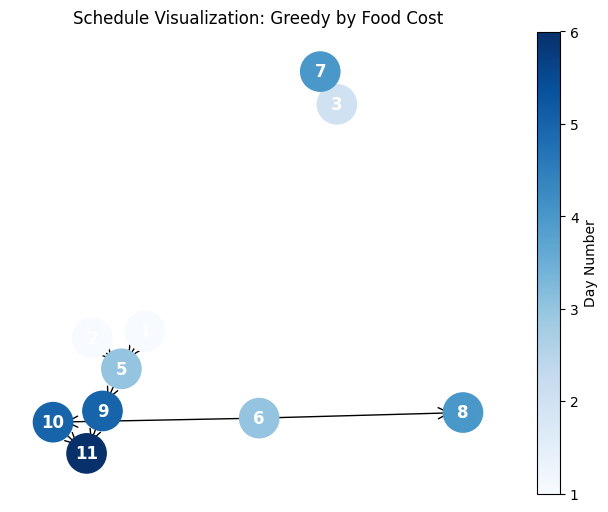

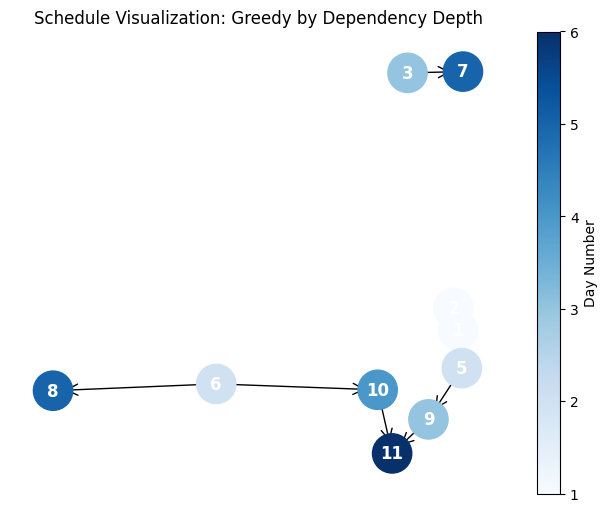

In [ ]:
import collections
import heapq
import networkx as nx
import matplotlib.pyplot as plt

class Scheduler:
    def __init__(self, assignments, food_costs, group_size):
        self.assignments = assignments
        self.food_costs = food_costs
        self.group_size = group_size
        self.all_tasks = set(assignments.keys())

    def get_available(self, completed):
        available = []
        for a_id, data in self.assignments.items():
            if a_id not in completed:
                if all(req in completed or str(req).startswith(('B', 'N'))
                       for req in data['req']):
                    available.append(a_id)
        return available

    def run_greedy(self, strategy="cost"):
        completed = set()
        history = []
        total_cost = 0
        day_num = 1

        while len(completed) < len(self.all_tasks):
            available = self.get_available(completed)
            if not available and len(completed) < len(self.all_tasks): # Handle cases where no tasks are available but not all are completed
                print("Warning: No available tasks but not all tasks completed. Possible unresolvable dependencies.")
                break

            if strategy == "cost":
                available.sort(key=lambda x: self.food_costs[self.assignments[x]['food']])
            elif strategy == "depth":
                available.sort(key=self._get_depth, reverse=True)

            todays_tasks = available[:self.group_size]

            day_menu_items = collections.defaultdict(int)
            for t in todays_tasks:
                day_menu_items[self.assignments[t]['food']] += 1

            day_cost = sum(self.food_costs[food] * count for food, count in day_menu_items.items())
            total_cost += day_cost

            history.append({
                "day": day_num,
                "tasks": todays_tasks,
                "menu": dict(day_menu_items), # Convert defaultdict to dict
                "cost": day_cost
            })
            completed.update(todays_tasks)
            day_num += 1

        return history, total_cost, day_num - 1

    def _get_depth(self, node_id):
        children = [a_id for a_id, data in self.assignments.items() if node_id in data['req']]
        return 1 + (max(self._get_depth(c) for c in children) if children else 0)

    def plot_schedule(self, history, title):
        G = nx.DiGraph()
        # Create edges from dependencies [cite: 134-144]
        for a_id, data in self.assignments.items():
            for req in data['req']:
                if isinstance(req, int):
                    G.add_edge(req, a_id)

        # Map each task to the day it was completed
        node_colors = {}
        for day_idx, day_data in enumerate(history):
            for task in day_data['tasks']:
                node_colors[task] = day_idx + 1

        pos = nx.spring_layout(G)
        plt.figure(figsize=(8, 6))

        # Draw nodes colored by Day
        colors = [node_colors.get(node, 0) for node in G.nodes()]
        nodes = nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.Blues, node_size=800)
        nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)
        nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold')

        plt.colorbar(nodes, label='Day Number')
        plt.title(f"Schedule Visualization: {title}")
        plt.axis('off')
        plt.show()

# --- Data [cite: 122-144] ---
costs = {"TC": 1, "PM": 1, "DF": 1, "GJ": 1}
group_size = 2 # Defined group_size
tasks = {
    1: {'req': ['B1', 'N1'], 'food': 'TC'}, 2: {'req': ['N2', 'B2'], 'food': 'TC'},
    3: {'req': ['B1', 'N1'], 'food': 'TC'}, 4: {'req': ['B2', 'N1'], 'food': 'PM'},
    5: {'req': [1, 2], 'food': 'TC'}, 6: {'req': ['N2', 'B3'], 'food': 'TC'},
    7: {'req': ['B3', 3], 'food': 'PM'}, 8: {'req': [6, 'N3'], 'food': 'GJ'},
    9: {'req': ['B1', 5], 'food': 'DF'}, 10: {'req': ['N1', 6], 'food': 'TC'},
    11: {'req': [9, 10], 'food': 'DF'}
}

# --- Execution ---
scheduler = Scheduler(tasks, costs, group_size) # Corrected class name

for strat in ["cost", "depth"]:
    print(f"\nStrategy: Greedy by {strat.capitalize()}")
    res, t_cost, t_days = scheduler.run_greedy(strategy=strat) # Unpack now matches return values
    for day in res:
        tasks_str = ", ".join([f"A{t}" for t in day['tasks']])
        menu_str = ", ".join([f"{count}-{food}" for food, count in day['menu'].items()])
        print(f"Day-{day['day']}: {tasks_str}")
        print(f"Menu: {menu_str}")
        print(f"Cost: {day['cost']}")
    print(f"Total Days: {t_days}")
    print(f"Total Cost: {t_cost}")

# --- Execute and Plot ---
s = Scheduler(tasks, costs, group_size=2)

# Plot Greedy Cost
hist_cost = s.run_greedy("cost")[0] # Only need history for plotting
s.plot_schedule(hist_cost, "Greedy by Food Cost")

# Plot Greedy Depth
hist_depth = s.run_greedy("depth")[0] # Only need history for plotting
s.plot_schedule(hist_depth, "Greedy by Dependency Depth")

Strategy: A* Search (Optimal Cost)
Day-1: A1
Menu: Counter({'TC': 1})
Cost: 1
Day-2: A2, A3
Menu: Counter({'TC': 2})
Cost: 2
Day-3: A4, A5
Menu: Counter({'PM': 1, 'TC': 1})
Cost: 2
Day-4: A6, A7
Menu: Counter({'TC': 1, 'PM': 1})
Cost: 2
Day-5: A9, A10
Menu: Counter({'DF': 1, 'TC': 1})
Cost: 2
Day-6: A8, A11
Menu: Counter({'GJ': 1, 'DF': 1})
Cost: 2
Total Days: 6
Total Cost: 11
States Explored: 1340
Optimal Total Cost: 11
States Explored: 1340


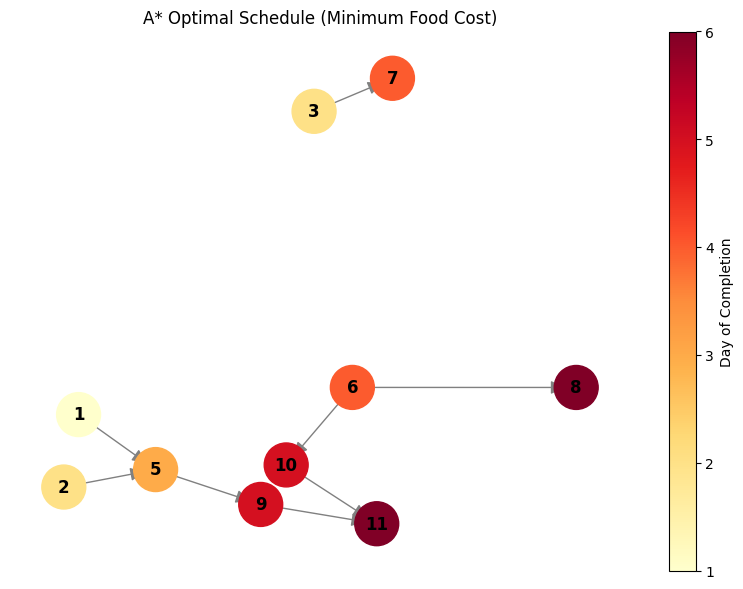

In [ ]:
import heapq
import itertools
import collections
import networkx as nx
import matplotlib.pyplot as plt

class AStarScheduler:
    def __init__(self, assignments, food_costs, group_size):
        self.assignments = assignments
        self.food_costs = food_costs
        self.group_size = group_size
        self.all_tasks = set(assignments.keys())

    def get_h(self, remaining_tasks):
        """
        Admissible Heuristic: Sum of the costs of all remaining tasks.
        It never overestimates because every task must be paid for at least once.
        """
        return sum(self.food_costs[self.assignments[t]['food']] for t in remaining_tasks)

    def get_available(self, completed):
        available = []
        for a_id, data in self.assignments.items():
            if a_id not in completed:
                # Prerequisites must be in completed or external (B/N) [cite: 102]
                if all(req in completed or str(req).startswith(('B', 'N'))
                       for req in data['req']):
                    available.append(a_id)
        return available

    def solve(self):
        # Priority Queue: (f_score, entry_count, g_score, completed_tuple, history)
        # entry_count is added to break ties when comparing non-comparable history objects.
        entry_count = 0
        start_node = (self.get_h(self.all_tasks), entry_count, 0, tuple(), [])
        queue = [start_node]
        visited = {} # Stores (completed_tuple: g_score)
        states_explored = 0

        while queue:
            f, count, g, completed, history = heapq.heappop(queue) # Unpack with count
            states_explored += 1

            completed_set = set(completed)
            if completed_set == self.all_tasks:
                return history, g, len(history), states_explored

            # The 'visited' dictionary should store the best 'g' found for a given 'completed' state.
            # When we extract from the heap, if we've already found a better or equal path to this state, skip it.
            if completed in visited and visited[completed] <= g:
                continue
            visited[completed] = g

            available = self.get_available(completed_set)

            # Explore all combinations of 1 to 'g' tasks for the next day [cite: 77]
            for r in range(1, min(len(available), self.group_size) + 1):
                for combo in itertools.combinations(available, r):
                    new_completed_list = sorted(list(completed_set | set(combo)))
                    new_completed = tuple(new_completed_list)

                    # Calculate Day Cost based on menu [cite: 10, 11]
                    day_menu = [self.assignments[t]['food'] for t in combo]
                    day_cost = sum(self.food_costs[food] for food in day_menu)

                    new_g = g + day_cost
                    new_h = self.get_h(self.all_tasks - set(new_completed))
                    new_history = history + [{"tasks": combo, "cost": day_cost, "menu": day_menu}]

                    entry_count += 1 # Increment for each new entry
                    heapq.heappush(queue, (new_g + new_h, entry_count, new_g, new_completed, new_history))
        return None

    def plot_optimal_path(self, history):
        G = nx.DiGraph()
        # Build graph edges from assignment data [cite: 134-144]
        for a_id, data in self.assignments.items():
            for req in data['req']:
                if isinstance(req, int):
                    G.add_edge(req, a_id)

        node_days = {}
        for day_idx, day_data in enumerate(history):
            for task in day_data['tasks']:
                node_days[task] = day_idx + 1

        plt.figure(figsize=(10, 7))
        pos = nx.spring_layout(G, seed=42)

        # Color nodes by the day they were solved
        colors = [node_days.get(n, 0) for n in G.nodes()]
        nodes = nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.YlOrRd, node_size=1000)
        nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
        nx.draw_networkx_labels(G, pos, font_weight='bold')

        plt.colorbar(nodes, label='Day of Completion')
        plt.title("A* Optimal Schedule (Minimum Food Cost)")
        plt.axis('off')
        plt.show()

# --- Configuration [cite: 122-127] ---
food_costs = {"TC": 1, "PM": 1, "DF": 1, "GJ": 1}
group_size = 2
tasks = {
    1: {'req': ['B1', 'N1'], 'food': 'TC'}, 2: {'req': ['N2', 'B2'], 'food': 'TC'},
    3: {'req': ['B1', 'N1'], 'food': 'TC'}, 4: {'req': ['B2', 'N1'], 'food': 'PM'},
    5: {'req': [1, 2], 'food': 'TC'}, 6: {'req': ['N2', 'B3'], 'food': 'TC'},
    7: {'req': ['B3', 3], 'food': 'PM'}, 8: {'req': [6, 'N3'], 'food': 'GJ'},
    9: {'req': ['B1', 5], 'food': 'DF'}, 10: {'req': ['N1', 6], 'food': 'TC'},
    11: {'req': [9, 10], 'food': 'DF'}
}

# --- Execution ---
solver = AStarScheduler(tasks, costs, group_size)
optimal_history, total_cost, total_days, explored = solver.solve()

print("Strategy: A* Search (Optimal Cost)")
for i, day in enumerate(optimal_history):
    print(f"Day-{i+1}: {', '.join(['A'+str(t) for t in day['tasks']])}")
    print(f"Menu: {collections.Counter(day['menu'])}")
    print(f"Cost: {day['cost']}")

print(f"Total Days: {total_days}")
print(f"Total Cost: {total_cost}")
print(f"States Explored: {explored}")

# --- Run and Plot ---
solver = AStarScheduler(tasks, food_costs, group_size)
opt_history, total_cost, days, explored = solver.solve()

print(f"Optimal Total Cost: {total_cost}")
print(f"States Explored: {explored}")
solver.plot_optimal_path(opt_history)
